<a href="https://colab.research.google.com/github/THOMAS-SARAH/Honeywell_Hackathon_Submission/blob/main/01_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Autonomous Production Choke Controller for a Single Naturally Flowing Oil Well

### Honeywell Hackathon

**Objective:** Develop an autonomous controller that adjusts the production choke opening to maximize oil production while ensuring all operating pressures remain within safe limits.

## 1. Importing Required Libraries

The following libraries are used for data manipulation, visualization, machine learning, and model evaluation. These tools help analyze the dataset, build predictive models, and simulate the autonomous choke controller.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## 2. Loading the Dataset

The simulated oil well dataset is loaded into a Pandas DataFrame. This dataset contains measurements of choke opening, oil production rate, and different pressure values recorded over time.

In [ ]:
df = pd.read_csv("data/Autonomous_Choke_Control_Simulated_Dataset.csv")

,Time_hr,Choke_pct,OilRate_bbl_hr,WHP_psi,FLP_psi,BHP_psi
0,0,30,90.00,250.00,180.00,3000.00
1,1,30,91.12,252.54,181.72,3017.37
2,2,30,91.45,254.71,183.67,3031.08
3,3,30,91.53,257.17,184.33,3040.00
4,4,30,92.17,257.61,184.26,3047.91


## 3. Dataset Overview

Before performing any analysis, the dataset is inspected to understand its structure, dimensions, column names, and sample records.

In [ ]:
df.head()

,Time_hr,Choke_pct,OilRate_bbl_hr,WHP_psi,FLP_psi,BHP_psi
0,0,30,90.00,250.00,180.00,3000.00
1,1,30,91.12,252.54,181.72,3017.37
2,2,30,91.45,254.71,183.67,3031.08
3,3,30,91.53,257.17,184.33,3040.00
4,4,30,92.17,257.61,184.26,3047.91


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Time_hr         120 non-null    int64  
 1   Choke_pct       120 non-null    int64  
 2   OilRate_bbl_hr  120 non-null    float64
 3   WHP_psi         120 non-null    float64
 4   FLP_psi         120 non-null    float64
 5   BHP_psi         120 non-null    float64
dtypes: float64(4), int64(2)
memory usage: 5.8 KB


In [ ]:
df.describe()

,Time_hr,Choke_pct,OilRate_bbl_hr,WHP_psi,FLP_psi,BHP_psi
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,59.500000,49.166667,125.423000,243.898000,172.284917,3018.426167
std,34.785054,12.270298,21.543691,15.644144,10.548468,69.113133
min,0.000000,30.000000,90.000000,216.250000,153.980000,2882.730000
25%,29.750000,40.000000,108.547500,233.590000,164.960000,2975.947500
50%,59.500000,50.000000,127.580000,243.190000,172.080000,3017.635000
75%,89.250000,57.500000,139.765000,259.500000,181.917500,3084.657500
max,119.000000,65.000000,158.660000,269.960000,189.070000,3137.480000


## 4. Data Quality Check

A preliminary data quality assessment is performed to identify missing or null values. This ensures the dataset is complete and suitable for further analysis.

In [ ]:
df.isnull().sum()

,0
Time_hr,0
Choke_pct,0
OilRate_bbl_hr,0
WHP_psi,0
FLP_psi,0
BHP_psi,0


## 5. Exploratory Data Analysis (EDA)

EDA helps understand the behavior of the oil well over time. Individual plots are generated for choke position, oil production rate, and various pressure measurements to observe trends and operational patterns.

The following plot illustrates how the oil production rate changes with time.

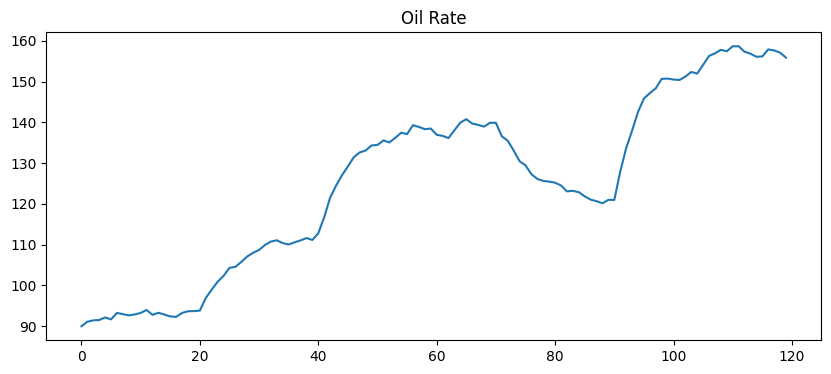

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(df["OilRate_bbl_hr"])
plt.title("Oil Rate")
plt.show()

## 6. Relationship Between Variables

Scatter plots are generated to study the relationship between choke opening and important operational parameters such as oil production and pressures.

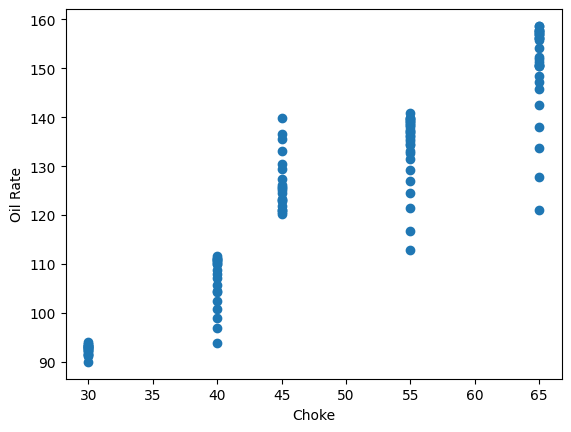

In [ ]:
plt.scatter(df["Choke_pct"],df["OilRate_bbl_hr"])
plt.xlabel("Choke")
plt.ylabel("Oil Rate")
plt.show()

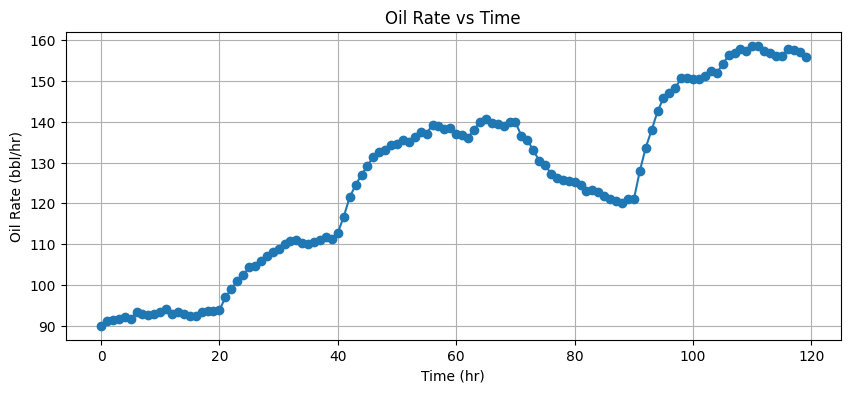

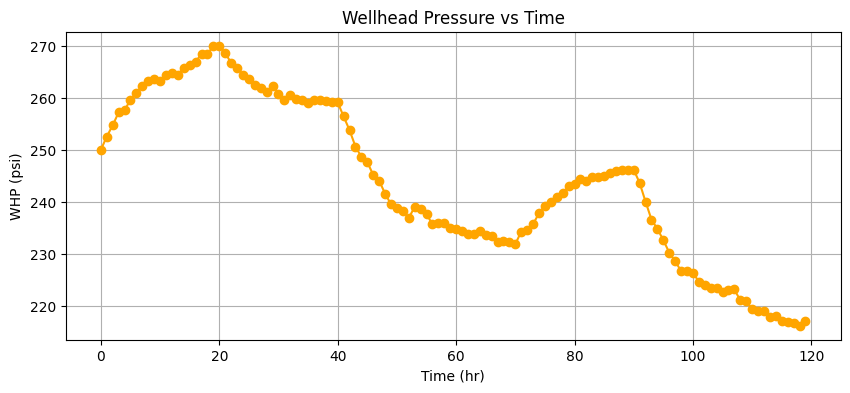

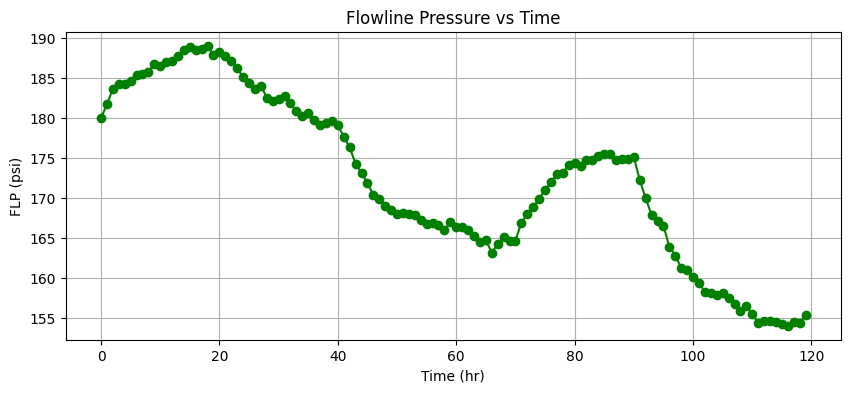

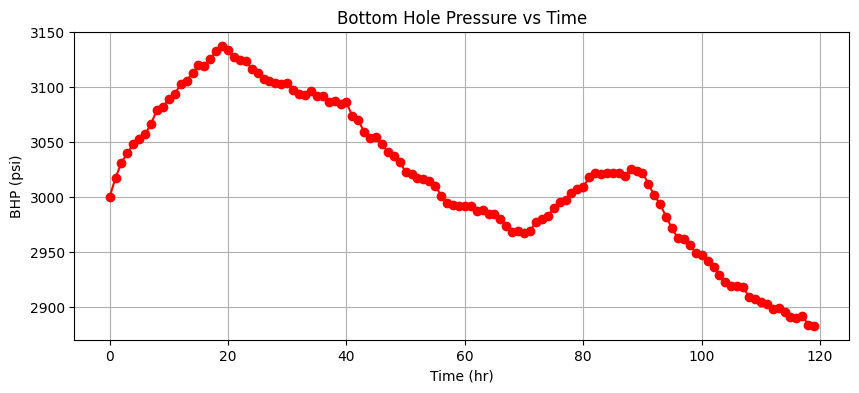

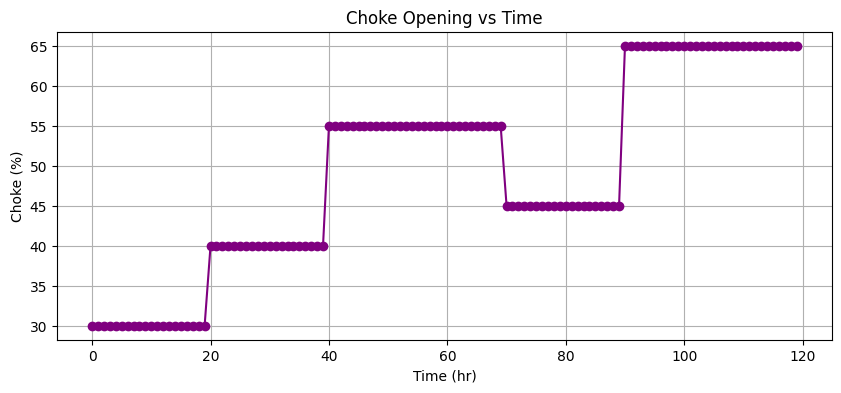

In [ ]:
import matplotlib.pyplot as plt

# Oil Rate
plt.figure(figsize=(10,4))
plt.plot(df["Time_hr"], df["OilRate_bbl_hr"], marker='o')
plt.title("Oil Rate vs Time")
plt.xlabel("Time (hr)")
plt.ylabel("Oil Rate (bbl/hr)")
plt.grid(True)
plt.show()

# Wellhead Pressure (WHP)
plt.figure(figsize=(10,4))
plt.plot(df["Time_hr"], df["WHP_psi"], marker='o', color='orange')
plt.title("Wellhead Pressure vs Time")
plt.xlabel("Time (hr)")
plt.ylabel("WHP (psi)")
plt.grid(True)
plt.show()

# Flowline Pressure (FLP)
plt.figure(figsize=(10,4))
plt.plot(df["Time_hr"], df["FLP_psi"], marker='o', color='green')
plt.title("Flowline Pressure vs Time")
plt.xlabel("Time (hr)")
plt.ylabel("FLP (psi)")
plt.grid(True)
plt.show()

# Bottom Hole Pressure (BHP)
plt.figure(figsize=(10,4))
plt.plot(df["Time_hr"], df["BHP_psi"], marker='o', color='red')
plt.title("Bottom Hole Pressure vs Time")
plt.xlabel("Time (hr)")
plt.ylabel("BHP (psi)")
plt.grid(True)
plt.show()

# Choke Opening
plt.figure(figsize=(10,4))
plt.plot(df["Time_hr"], df["Choke_pct"], marker='o', color='purple')
plt.title("Choke Opening vs Time")
plt.xlabel("Time (hr)")
plt.ylabel("Choke (%)")
plt.grid(True)
plt.show()

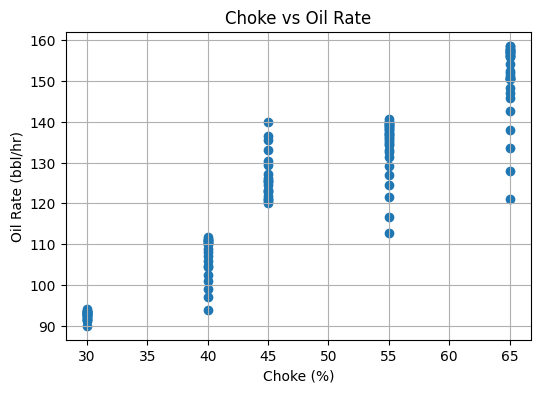

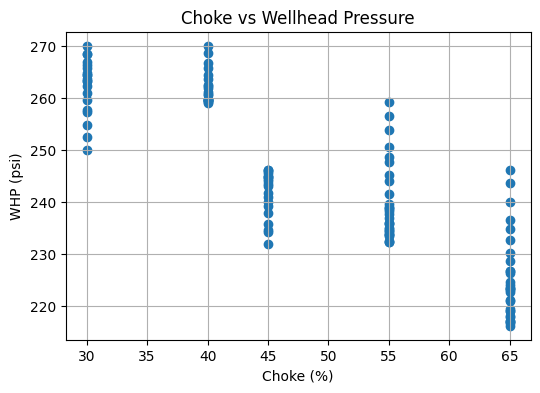

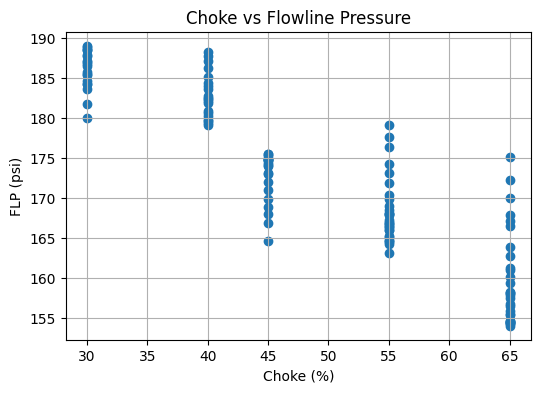

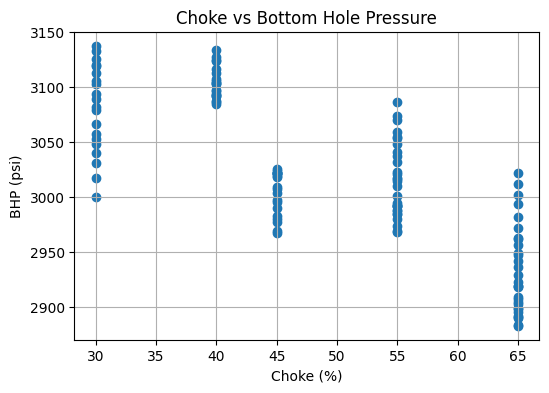

In [ ]:
import matplotlib.pyplot as plt

# Choke vs Oil Rate
plt.figure(figsize=(6,4))
plt.scatter(df["Choke_pct"], df["OilRate_bbl_hr"])
plt.title("Choke vs Oil Rate")
plt.xlabel("Choke (%)")
plt.ylabel("Oil Rate (bbl/hr)")
plt.grid(True)
plt.show()

# Choke vs WHP
plt.figure(figsize=(6,4))
plt.scatter(df["Choke_pct"], df["WHP_psi"])
plt.title("Choke vs Wellhead Pressure")
plt.xlabel("Choke (%)")
plt.ylabel("WHP (psi)")
plt.grid(True)
plt.show()

# Choke vs FLP
plt.figure(figsize=(6,4))
plt.scatter(df["Choke_pct"], df["FLP_psi"])
plt.title("Choke vs Flowline Pressure")
plt.xlabel("Choke (%)")
plt.ylabel("FLP (psi)")
plt.grid(True)
plt.show()

# Choke vs BHP
plt.figure(figsize=(6,4))
plt.scatter(df["Choke_pct"], df["BHP_psi"])
plt.title("Choke vs Bottom Hole Pressure")
plt.xlabel("Choke (%)")
plt.ylabel("BHP (psi)")
plt.grid(True)
plt.show()

## 7. Correlation Analysis

A correlation heatmap is used to identify relationships between all numerical variables. This helps determine which features are strongly associated with oil production.

<Axes: >

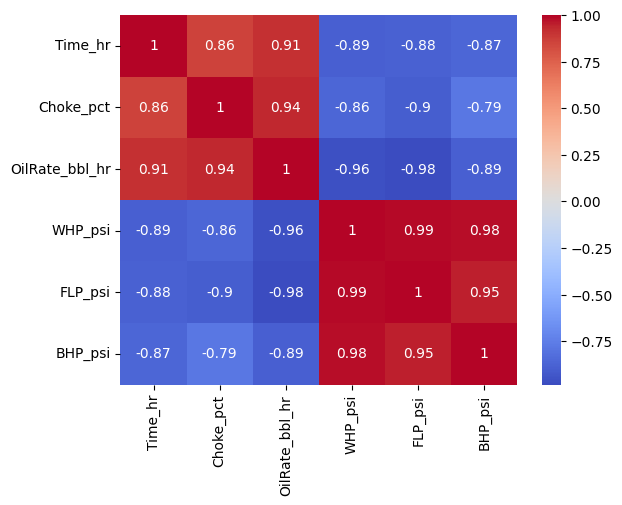

In [ ]:
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")

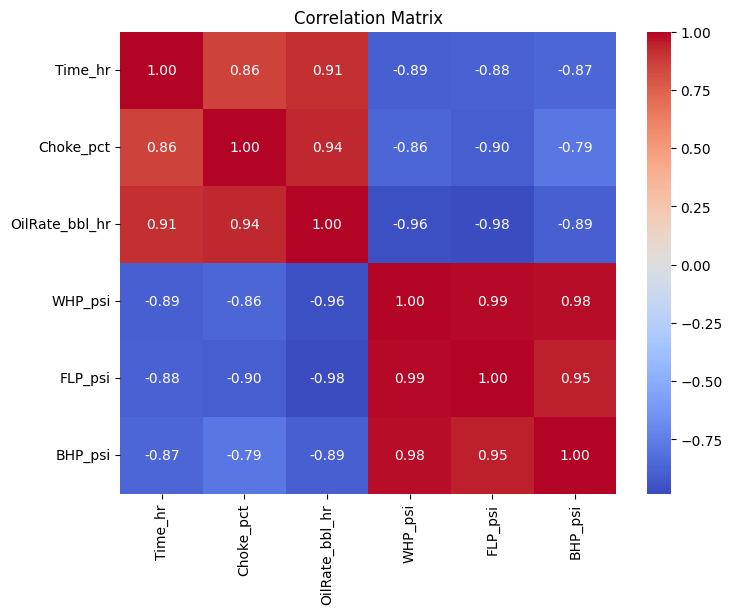

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [ ]:
df = df.sort_values("Time_hr").reset_index(drop=True)

In [ ]:
df["Choke_Change"] = df["Choke_pct"].diff()

changes = df[df["Choke_Change"] != 0]

changes[["Time_hr", "Choke_pct", "Choke_Change"]]

,Time_hr,Choke_pct,Choke_Change
0,0,30,NaN
20,20,40,10.0
40,40,55,15.0
70,70,45,-10.0
90,90,65,20.0


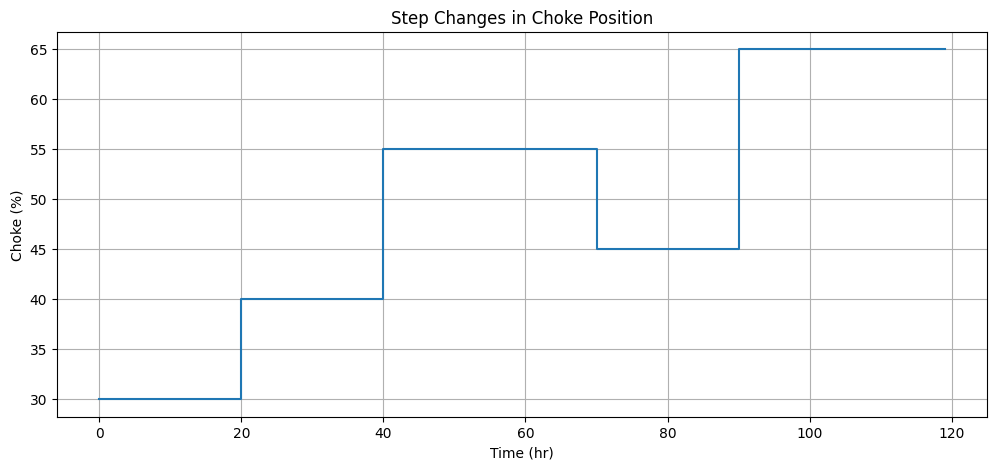

In [ ]:
plt.figure(figsize=(12,5))

plt.step(df["Time_hr"], df["Choke_pct"], where="post")

plt.xlabel("Time (hr)")
plt.ylabel("Choke (%)")
plt.title("Step Changes in Choke Position")

plt.grid(True)

plt.show()

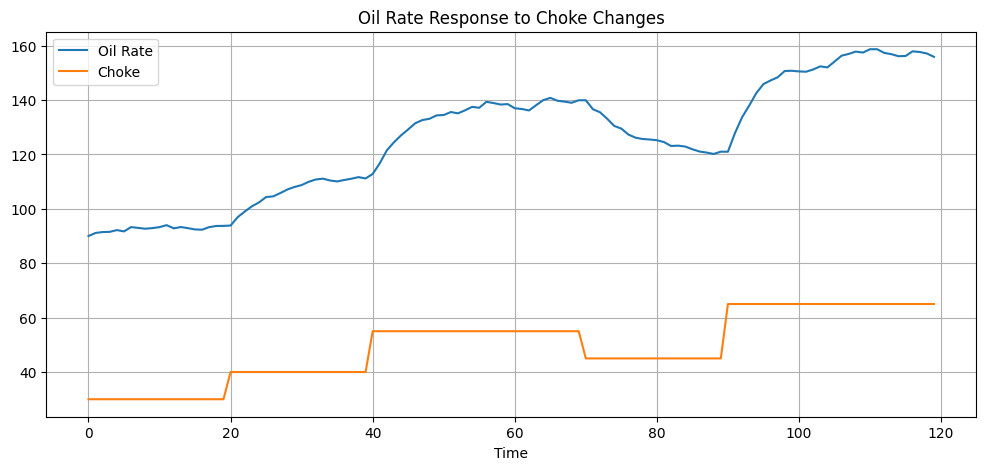

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(df["Time_hr"], df["OilRate_bbl_hr"], label="Oil Rate")
plt.plot(df["Time_hr"], df["Choke_pct"], label="Choke")

plt.legend()

plt.xlabel("Time")
plt.title("Oil Rate Response to Choke Changes")

plt.grid(True)

plt.show()

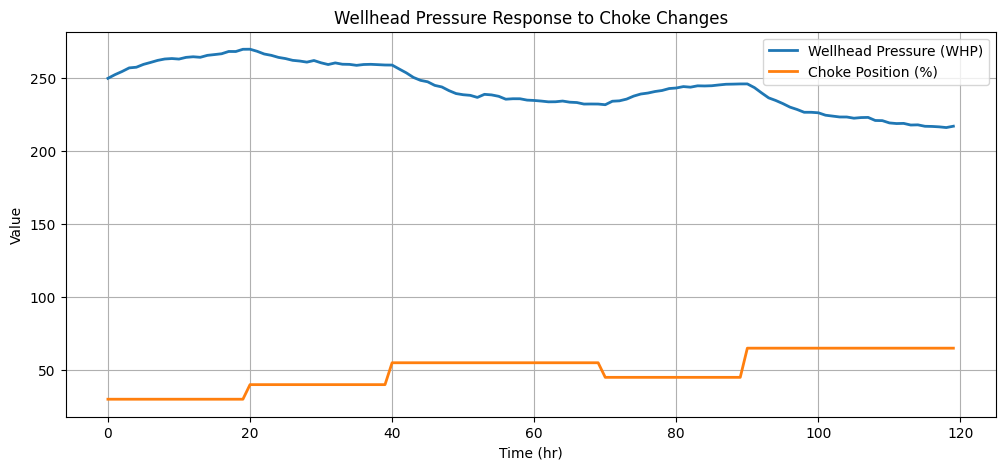

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(df["Time_hr"], df["WHP_psi"], label="Wellhead Pressure (WHP)", linewidth=2)
plt.plot(df["Time_hr"], df["Choke_pct"], label="Choke Position (%)", linewidth=2)

plt.xlabel("Time (hr)")
plt.ylabel("Value")
plt.title("Wellhead Pressure Response to Choke Changes")

plt.legend()
plt.grid(True)

plt.show()

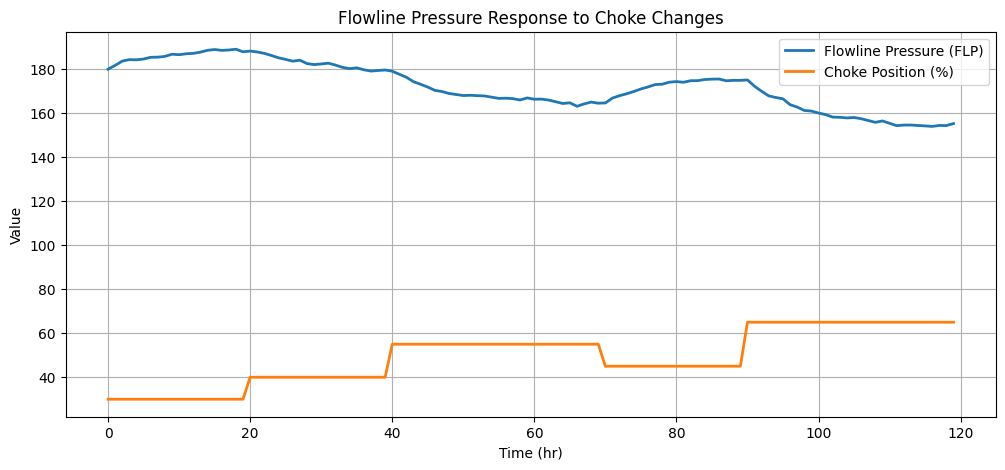

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(df["Time_hr"], df["FLP_psi"], label="Flowline Pressure (FLP)", linewidth=2)
plt.plot(df["Time_hr"], df["Choke_pct"], label="Choke Position (%)", linewidth=2)

plt.xlabel("Time (hr)")
plt.ylabel("Value")
plt.title("Flowline Pressure Response to Choke Changes")

plt.legend()
plt.grid(True)

plt.show()

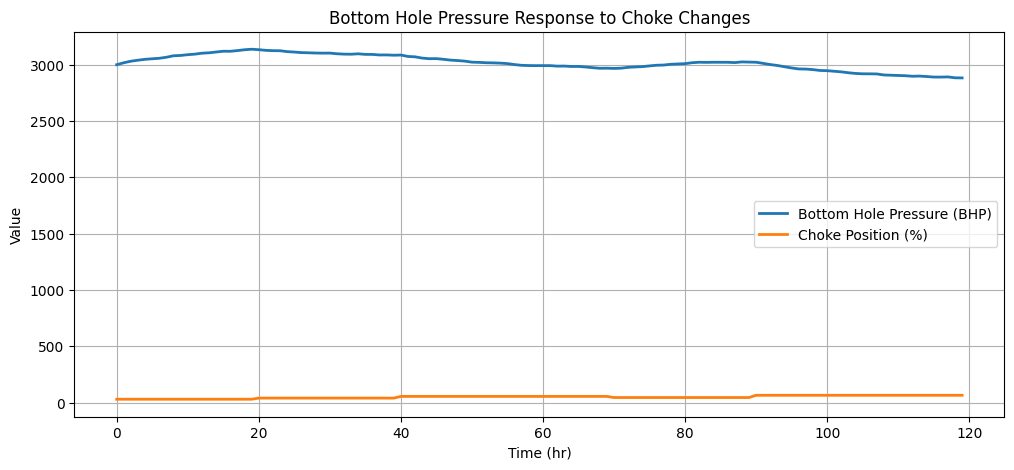

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(df["Time_hr"], df["BHP_psi"], label="Bottom Hole Pressure (BHP)", linewidth=2)
plt.plot(df["Time_hr"], df["Choke_pct"], label="Choke Position (%)", linewidth=2)

plt.xlabel("Time (hr)")
plt.ylabel("Value")
plt.title("Bottom Hole Pressure Response to Choke Changes")

plt.legend()
plt.grid(True)

plt.show()

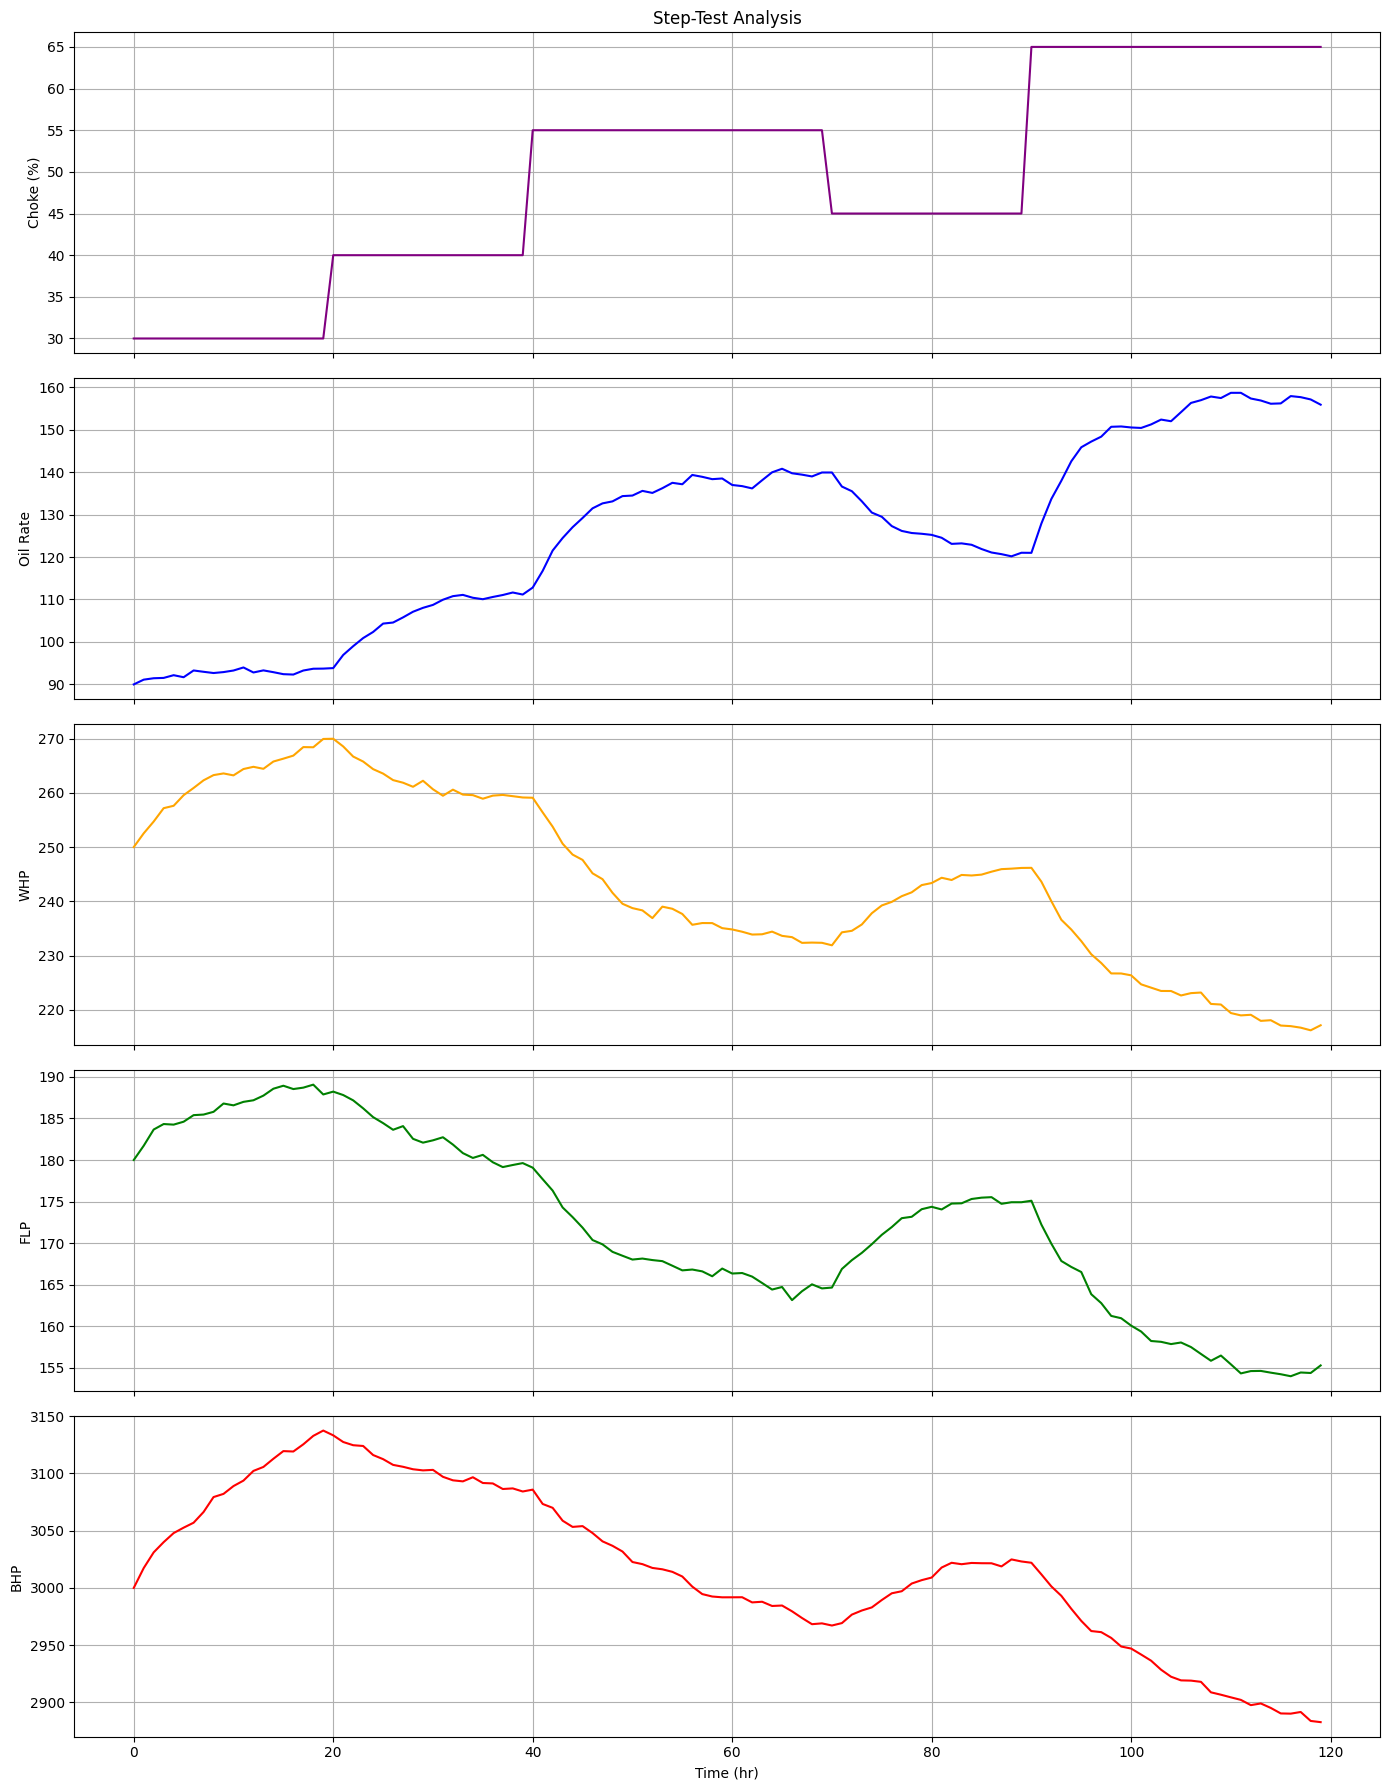

In [ ]:
fig, ax = plt.subplots(5, 1, figsize=(14, 18), sharex=True)

ax[0].plot(df["Time_hr"], df["Choke_pct"], color='purple')
ax[0].set_ylabel("Choke (%)")
ax[0].set_title("Step-Test Analysis")

ax[1].plot(df["Time_hr"], df["OilRate_bbl_hr"], color='blue')
ax[1].set_ylabel("Oil Rate")

ax[2].plot(df["Time_hr"], df["WHP_psi"], color='orange')
ax[2].set_ylabel("WHP")

ax[3].plot(df["Time_hr"], df["FLP_psi"], color='green')
ax[3].set_ylabel("FLP")

ax[4].plot(df["Time_hr"], df["BHP_psi"], color='red')
ax[4].set_ylabel("BHP")
ax[4].set_xlabel("Time (hr)")

for axis in ax:
    axis.grid(True)

plt.tight_layout()
plt.show()

## 9. Dynamic Model Development

Machine learning models are developed to predict oil production and pressure values based on the choke opening. These predictive models act as a surrogate for the physical oil well during controller simulation.

In [ ]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
X = df[["Choke_pct"]]

In [ ]:
y_oil = df["OilRate_bbl_hr"]

y_whp = df["WHP_psi"]

y_flp = df["FLP_psi"]

y_bhp = df["BHP_psi"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_oil,
    test_size=0.2,
    random_state=42
)

In [ ]:
oil_model = LinearRegression()

oil_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
oil_pred = oil_model.predict(X_test)

In [ ]:
print("Oil Rate Model")

print("MAE :", mean_absolute_error(y_test, oil_pred))

print("RMSE :", mean_squared_error(y_test, oil_pred) ** 0.5)

print("R2 Score :", r2_score(y_test, oil_pred))

Oil Rate Model
MAE : 5.799795609931631
RMSE : 9.183104976797132
R2 Score : 0.7999066667217973


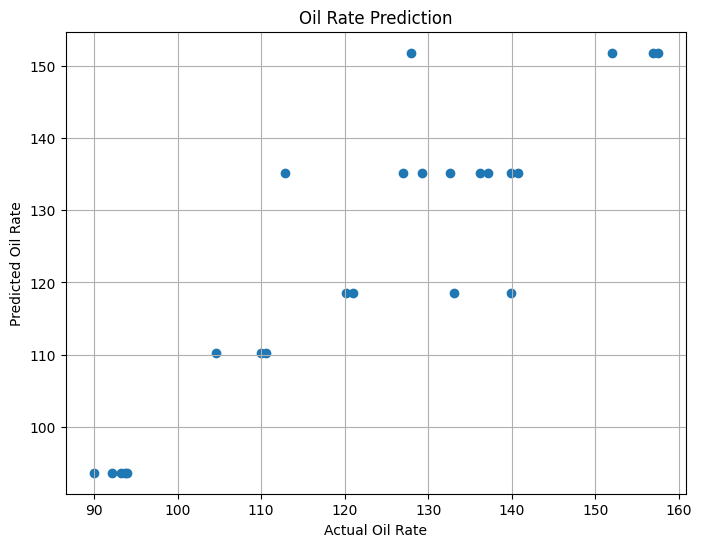

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, oil_pred)

plt.xlabel("Actual Oil Rate")

plt.ylabel("Predicted Oil Rate")

plt.title("Oil Rate Prediction")

plt.grid(True)

plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_whp,
    test_size=0.2,
    random_state=42
)

whp_model = LinearRegression()

whp_model.fit(X_train, y_train)

whp_pred = whp_model.predict(X_test)

print("WHP")

print("R2 =", r2_score(y_test, whp_pred))

WHP
R2 = 0.5466693350719655


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_flp,
    test_size=0.2,
    random_state=42
)

flp_model = LinearRegression()

flp_model.fit(X_train, y_train)

flp_pred = flp_model.predict(X_test)

print("FLP")

print("R2 =", r2_score(y_test, flp_pred))

FLP
R2 = 0.7048151531919474


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_bhp,
    test_size=0.2,
    random_state=42
)

bhp_model = LinearRegression()

bhp_model.fit(X_train, y_train)

bhp_pred = bhp_model.predict(X_test)

print("BHP")

print("R2 =", r2_score(y_test, bhp_pred))

BHP
R2 = 0.3744250342105274


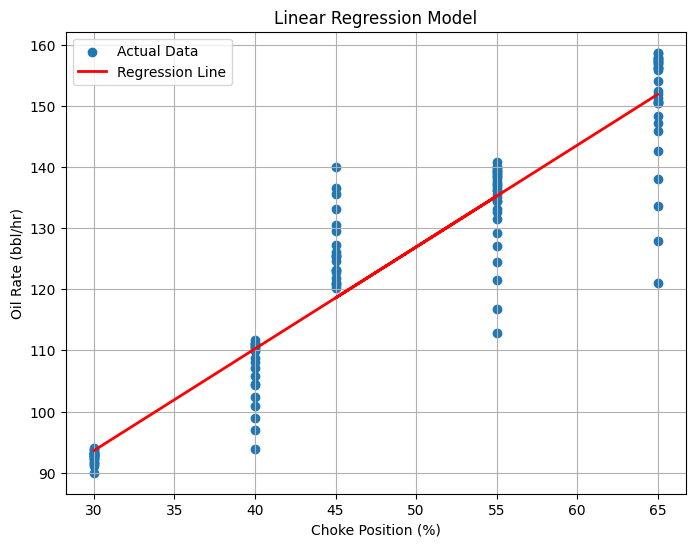

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(df["Choke_pct"], df["OilRate_bbl_hr"], label="Actual Data")

plt.plot(
    df["Choke_pct"],
    oil_model.predict(X),
    color='red',
    linewidth=2,
    label="Regression Line"
)

plt.xlabel("Choke Position (%)")

plt.ylabel("Oil Rate (bbl/hr)")

plt.title("Linear Regression Model")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
MAX_CHOKE = 100
MIN_CHOKE = 0
MAX_STEP = 5

MAX_WHP = df["WHP_psi"].max()
MIN_WHP = df["WHP_psi"].min()

MAX_FLP = df["FLP_psi"].max()
MIN_FLP = df["FLP_psi"].min()

MAX_BHP = df["BHP_psi"].max()
MIN_BHP = df["BHP_psi"].min()

In [ ]:
def generate_candidates(current_choke):

    start = max(MIN_CHOKE, current_choke - MAX_STEP)

    end = min(MAX_CHOKE, current_choke + MAX_STEP)

    return list(range(int(start), int(end)+1))

In [ ]:
def predict_outputs(choke):

    x = [[choke]]

    oil = oil_model.predict(x)[0]

    whp = whp_model.predict(x)[0]

    flp = flp_model.predict(x)[0]

    bhp = bhp_model.predict(x)[0]

    return oil, whp, flp, bhp

In [ ]:
def is_safe(whp, flp, bhp):

    return (

        MIN_WHP <= whp <= MAX_WHP and

        MIN_FLP <= flp <= MAX_FLP and

        MIN_BHP <= bhp <= MAX_BHP

    )

In [ ]:
def choose_best_choke(current_choke, target):

    candidates = generate_candidates(current_choke)

    best = current_choke

    best_error = float("inf")

    for choke in candidates:

        oil, whp, flp, bhp = predict_outputs(choke)

        if not is_safe(whp, flp, bhp):
            continue

        error = abs(target - oil)

        if error < best_error:

            best_error = error

            best = choke

    return best

In [ ]:
current_choke = 45

target = 150

best = choose_best_choke(current_choke, target)

print(best)

50


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/

In [ ]:
current_choke = 40

target = 150

history = []

for hour in range(24):

    current_choke = choose_best_choke(current_choke, target)

    oil, whp, flp, bhp = predict_outputs(current_choke)

    history.append([hour,
                    current_choke,
                    oil,
                    whp,
                    flp,
                    bhp])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/

In [ ]:
history = pd.DataFrame(history,
                       columns=[
                           "Hour",
                           "Choke",
                           "Oil",
                           "WHP",
                           "FLP",
                           "BHP"
                       ])

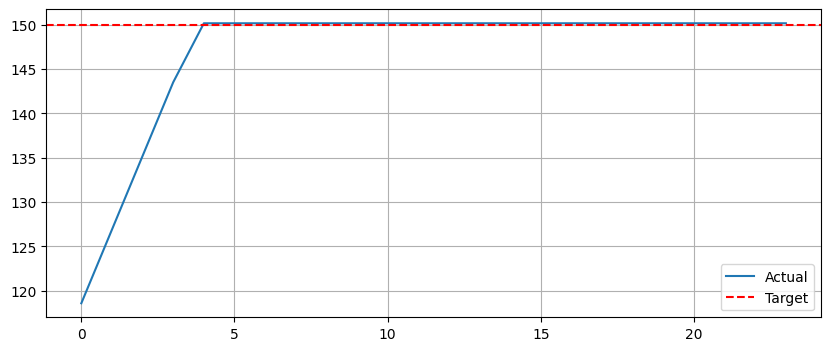

In [ ]:
plt.figure(figsize=(10,4))

plt.plot(history["Hour"], history["Oil"], label="Actual")

plt.axhline(target, color="red", linestyle="--", label="Target")

plt.legend()

plt.grid()

plt.show()

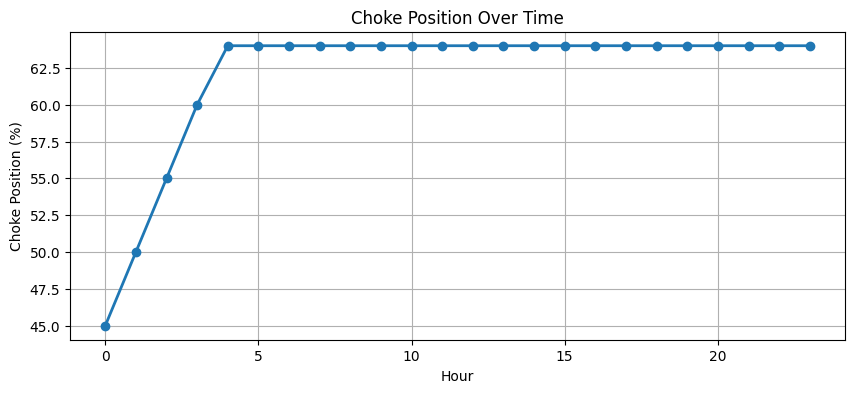

In [ ]:
plt.figure(figsize=(10,4))

plt.plot(history["Hour"], history["Choke"], marker='o', linewidth=2)

plt.title("Choke Position Over Time")
plt.xlabel("Hour")
plt.ylabel("Choke Position (%)")

plt.grid(True)

plt.show()

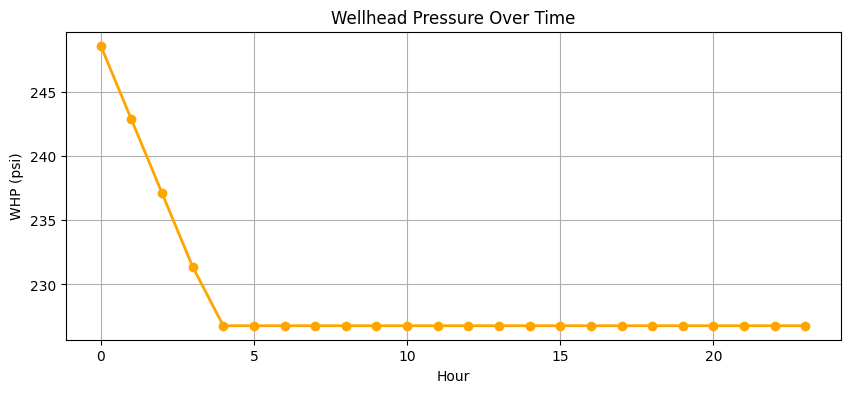

In [ ]:
plt.figure(figsize=(10,4))

plt.plot(history["Hour"], history["WHP"], marker='o', linewidth=2, color='orange')

plt.title("Wellhead Pressure Over Time")
plt.xlabel("Hour")
plt.ylabel("WHP (psi)")

plt.grid(True)

plt.show()

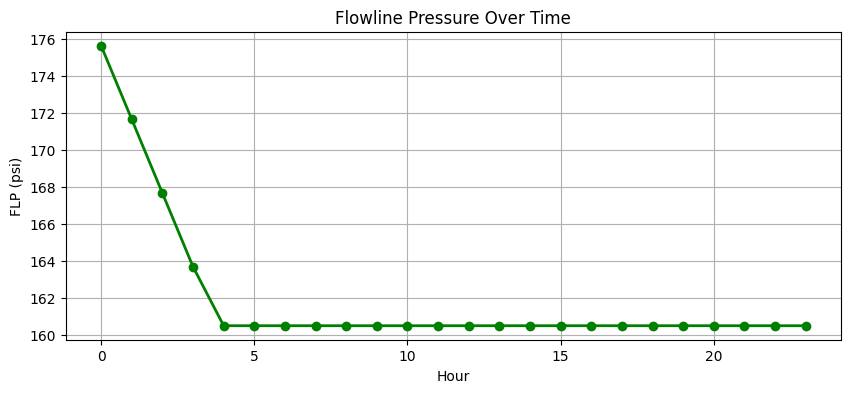

In [ ]:
plt.figure(figsize=(10,4))

plt.plot(history["Hour"], history["FLP"], marker='o', linewidth=2, color='green')

plt.title("Flowline Pressure Over Time")
plt.xlabel("Hour")
plt.ylabel("FLP (psi)")

plt.grid(True)

plt.show()

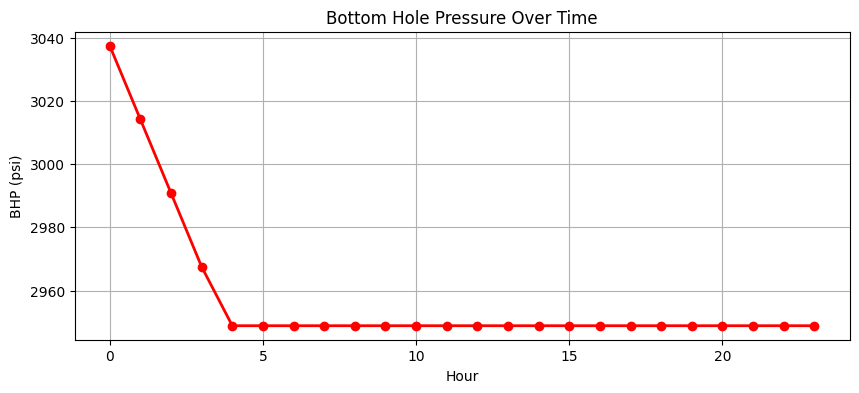

In [ ]:
plt.figure(figsize=(10,4))

plt.plot(history["Hour"], history["BHP"], marker='o', linewidth=2, color='red')

plt.title("Bottom Hole Pressure Over Time")
plt.xlabel("Hour")
plt.ylabel("BHP (psi)")

plt.grid(True)

plt.show()

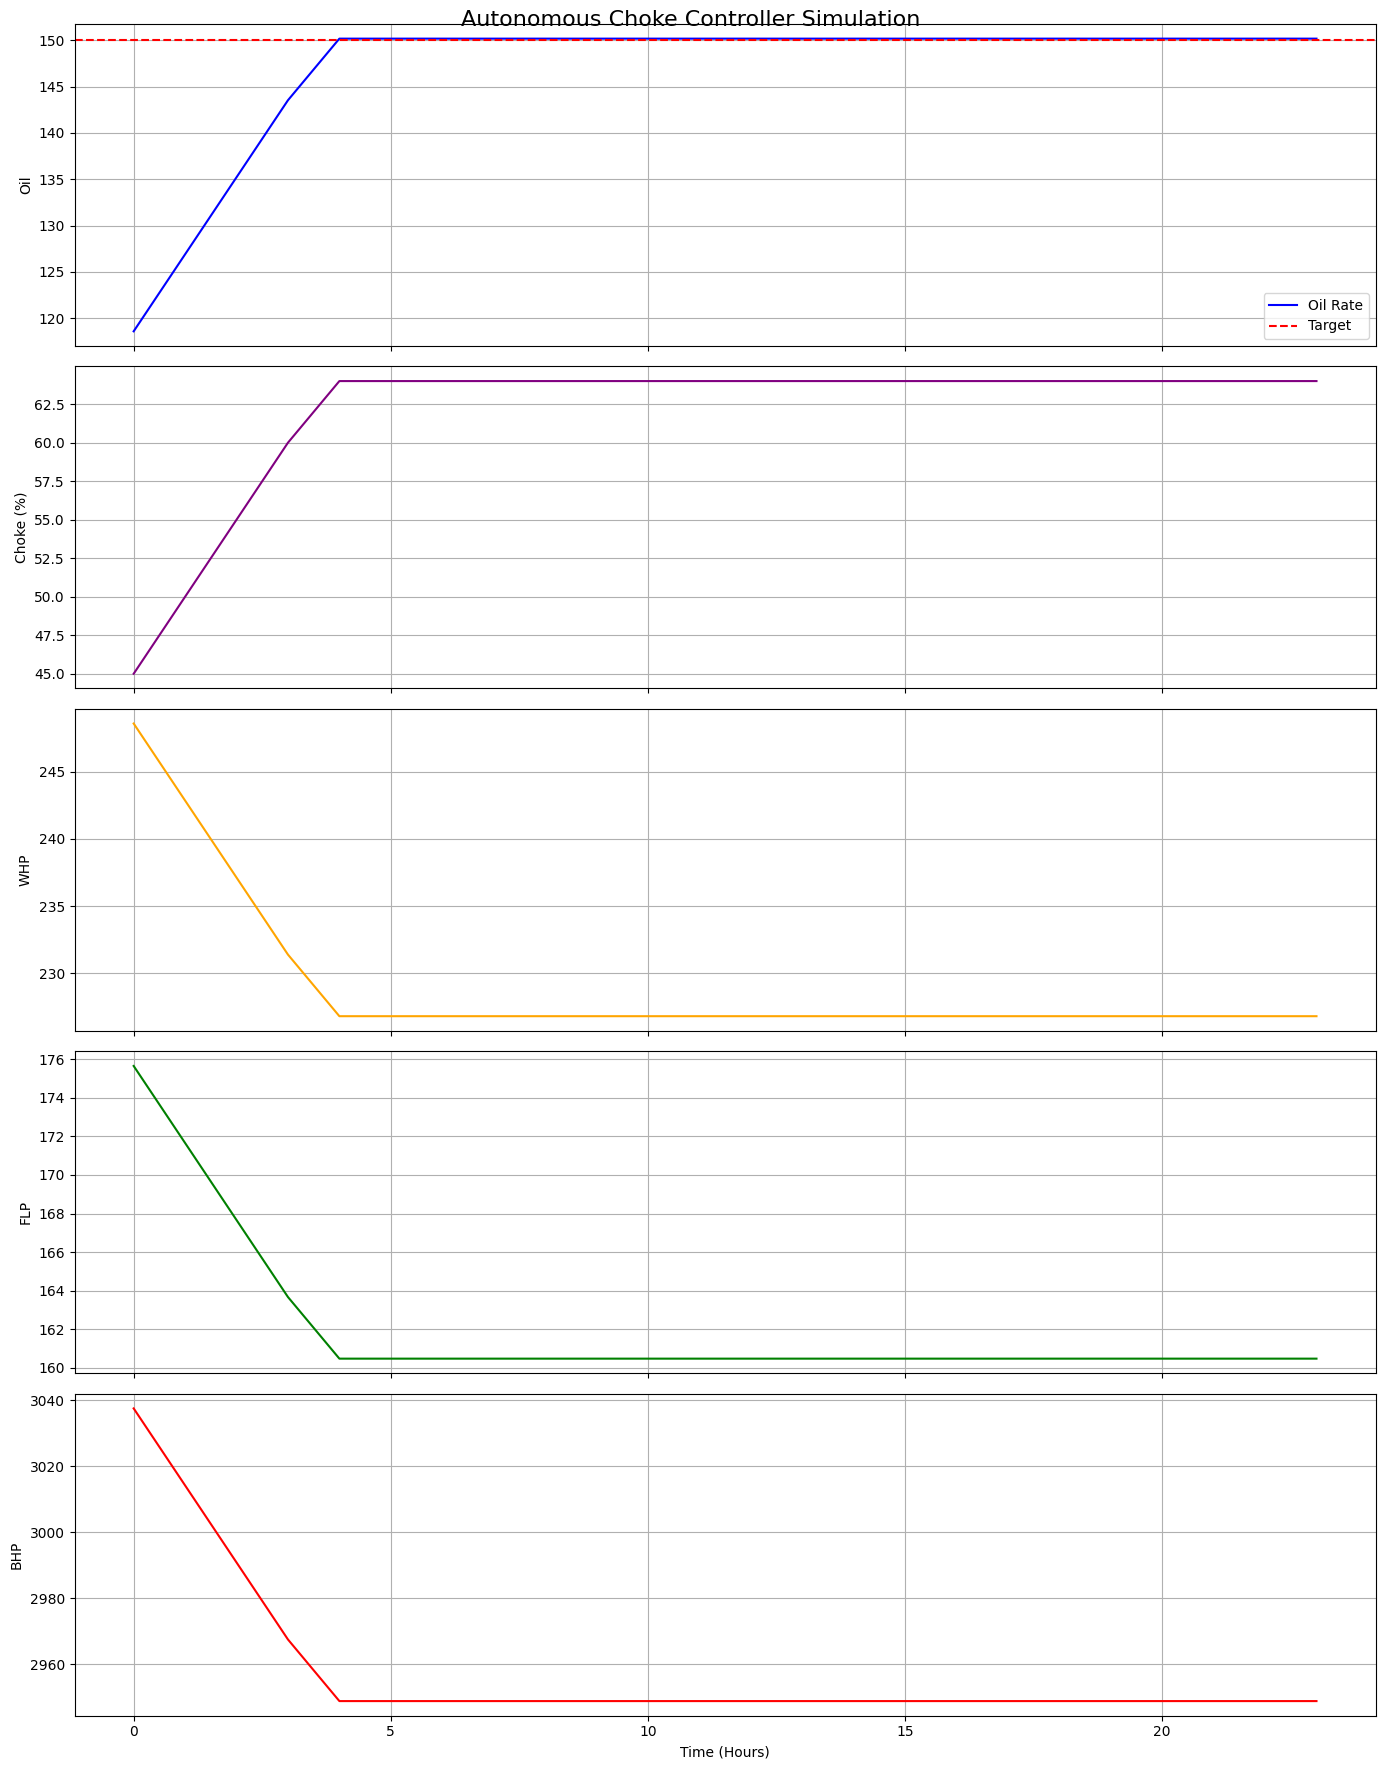

In [ ]:
fig, ax = plt.subplots(5, 1, figsize=(14, 18), sharex=True)

# Oil Rate
ax[0].plot(history["Hour"], history["Oil"], label="Oil Rate", color="blue")
ax[0].axhline(target, color="red", linestyle="--", label="Target")
ax[0].set_ylabel("Oil")
ax[0].legend()
ax[0].grid(True)

# Choke
ax[1].plot(history["Hour"], history["Choke"], color="purple")
ax[1].set_ylabel("Choke (%)")
ax[1].grid(True)

# WHP
ax[2].plot(history["Hour"], history["WHP"], color="orange")
ax[2].set_ylabel("WHP")
ax[2].grid(True)

# FLP
ax[3].plot(history["Hour"], history["FLP"], color="green")
ax[3].set_ylabel("FLP")
ax[3].grid(True)

# BHP
ax[4].plot(history["Hour"], history["BHP"], color="red")
ax[4].set_ylabel("BHP")
ax[4].set_xlabel("Time (Hours)")
ax[4].grid(True)

plt.suptitle("Autonomous Choke Controller Simulation", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
current_choke = 20
target = 120

history_A = []

for hour in range(24):

    current_choke = choose_best_choke(current_choke, target)

    oil, whp, flp, bhp = predict_outputs(current_choke)

    history_A.append([
        hour,
        current_choke,
        oil,
        whp,
        flp,
        bhp
    ])

history_A = pd.DataFrame(
    history_A,
    columns=["Hour","Choke","Oil","WHP","FLP","BHP"]
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/

In [ ]:
targets = [100]*8 + [140]*8 + [160]*8

current_choke = 30

history_B = []

for hour in range(24):

    target = targets[hour]

    current_choke = choose_best_choke(current_choke, target)

    oil, whp, flp, bhp = predict_outputs(current_choke)

    history_B.append([
        hour,
        target,
        current_choke,
        oil,
        whp,
        flp,
        bhp
    ])

history_B = pd.DataFrame(
    history_B,
    columns=[
        "Hour",
        "Target",
        "Choke",
        "Oil",
        "WHP",
        "FLP",
        "BHP"
    ]
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/

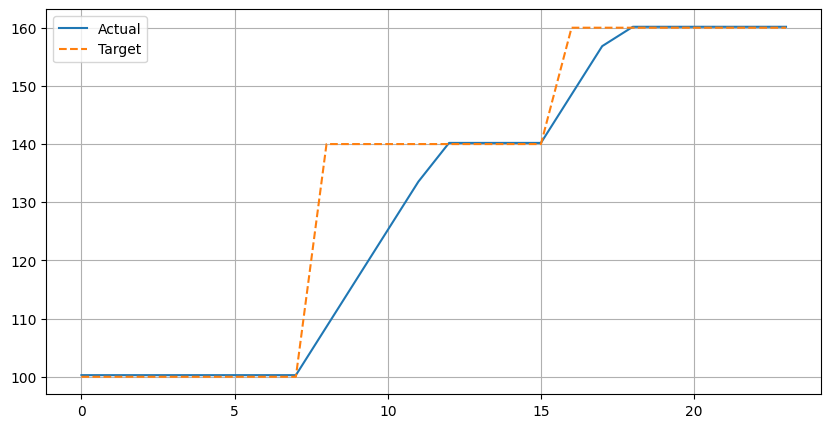

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history_B["Hour"], history_B["Oil"], label="Actual")
plt.plot(history_B["Hour"], history_B["Target"], '--', label="Target")

plt.legend()

plt.grid()

plt.show()

In [ ]:
target = 250

current_choke = 40

history_C = []

for hour in range(24):

    current_choke = choose_best_choke(current_choke, target)

    oil, whp, flp, bhp = predict_outputs(current_choke)

    history_C.append([
        hour,
        current_choke,
        oil,
        whp,
        flp,
        bhp
    ])

history_C = pd.DataFrame(
    history_C,
    columns=[
        "Hour",
        "Choke",
        "Oil",
        "WHP",
        "FLP",
        "BHP"
    ]
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/

In [ ]:
summary = pd.DataFrame({
    "Scenario": ["A", "B", "C"],
    "Description": [
        "Startup to Target",
        "Changing Target",
        "Impossible Target"
    ],
    "Result": [
        "Reached Target",
        "Tracked Target",
        "Maintained Safe Operation"
    ]
})

summary

,Scenario,Description,Result
0,A,Startup to Target,Reached Target
1,B,Changing Target,Tracked Target
2,C,Impossible Target,Maintained Safe Operation


In [ ]:
def get_well_response(choke):
    # For now
    return predict_outputs(choke)

